# <b>Climate Impacts on Fish Stocks Analysis Capstone Project</b>
Author: Daisy Chu
<br>Date: 3/10/2026</br>
## Environmental Research Question: 
- How does ocean temperature and salinity impact number of fish landings in Portugal?

Link to GitHub repository (FIX THIS): [GitHub Repository](<insert link here>)

## Part 1: Loading and Cleaning Data

### Loading Raw Data

In [1]:
# Load libraries
library(dplyr)
library(ggplot2)
library(tidyverse)
library(ggpubr)
library(Hmisc)


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ purrr     1.1.0     ✔ tidyr     1.3.1
✔ readr     2.1.5     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘Hmisc’




The following objects are masked from ‘package:dplyr’:

    src, summarize




The following objects are masked from ‘package:base’:

    format.pval, units




In [7]:
# Check files in raw data folder
setwd("../data/raw_data")
list.files()

[1] "1903-1949_Landings.csv"                                  
 [2] "ASFIS_sp_2025.csv"                                       
 [3] "atlantic_ocean_temp.csv"                                 
 [4] "BICC_211_Timeseries.csv"                                 
 [5] "countries_iso3166b.csv"                                  
 [6] "FINAL_Jahat_Garcia_-_MPA_DATA_SET_-_mpa_atlas_export.csv"
 [7] "ICES_1950-2010.csv"                                      
 [8] "ICESCatchDataset2006-2023.csv"                           
 [9] "portugal_fishery_stats.csv"                              
[10] "README.md"

In [8]:
# Load datasets
landings_1903 <- read.csv("1903-1949_Landings.csv")
landings_1950 <- read.csv("ICES_1950-2010.csv")
landings_2006 <- read.csv("ICESCatchDataset2006-2023.csv")
atlantic_climate <- read.csv("atlantic_ocean_temp.csv")
iso_code <- read.csv("countries_iso3166b.csv")
fish_cost <- read.csv("portugal_fishery_stats.csv")
spec_names <- read.csv("ASFIS_sp_2025.csv")

In [6]:
# Explore datasets
#head(landings_1903)
#head(landings_1950)
#head(landings_2006)

,Country,Year,FAO_Area,FAO_Species_Code,FAO_Species_Name,Species.scientific.name,Landings
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,BEL,1904,IV,BLL,Brill,Scophthalmus rhombus,29
2,BEL,1904,IV,DAB,Common dab,Limanda limanda,213
3,BEL,1904,IV,FIN,Finfishes nei,Osteichthyes,410
4,BEL,1904,IV,FLE,European flounder,Platichthys flesus,7
5,BEL,1904,IV,HAL,Atlantic halibut,Hippoglossus hippoglossus,1
6,BEL,1904,IV,LEM,Lemon sole,Microstomus kitt,14


In [4]:
# Tidy up column names of each fish landings dataset
landings_1903_clean <- landings_1903 %>%
  rename(country = Country,
         year = Year,
         fao_area = FAO_Area,
         species_code = FAO_Species_Code,
         species_name = FAO_Species_Name,
         species_scientific_name = Species.scientific.name,
         landings = Landings) %>%
  mutate(landings = as.numeric(landings), year = as.numeric(year))

landings_1950_clean <- landings_1950 %>%
  rename(country = Country,
         species_name = Species,
         fao_division = Division) %>%
  rename_with(~ str_remove(., "^X")) %>%
  mutate(across("1950":"2010", as.numeric)) %>%
  select(-"2006":-"2010")
  

landings_2006_clean <- landings_2006 %>%
  rename(species_code = Species,
         fao_area = Area,
         units = Units,
         country = Country) %>%
  rename_with(~ str_remove(., "^X")) %>%
  mutate(across("2006":"2023", as.numeric))

head(landings_1950_clean)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `landings = as.numeric(landings)`.
Caused by warning:
! NAs introduced by coercion”


Warning message:
“There were 61 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across("1950":"2010", as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 60 remaining warnings.”


Warning message:
“There were 2 warnings in `mutate()`.
The first warning was:
ℹ In argument: `across("2006":"2023", as.numeric)`.
Caused by warning:
! NAs introduced by coercion
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”


,country,species_name,fao_division,1950,1951,1952,1953,1954,1955,1956,⋯,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Belgium,Anglerfishes nei,IV b,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,Belgium,Anglerfishes nei,IV c,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,Belgium,Anglerfishes nei,VII a,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,Belgium,Anglerfishes nei,VII b,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,Belgium,Anglerfishes nei,VII d,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,Belgium,Anglerfishes nei,VII e,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [42]:
# Create a dataset that contains both species 3 letter code and name
spec_code_name <- spec_names %>%
  select(Alpha3_Code, English_name) %>%
  rename(species_code = Alpha3_Code,
         species_name = English_name)

head(spec_code_name)

,species_code,species_name
,<chr>,<chr>
1,GXM,Siamese algae-eater
2,CDO,River carpsucker
3,FMP,Quillback
4,ATC,Longnose sucker
5,ATO,White sucker
6,ATS,Flannelmouth sucker


species_code,species_name
<chr>,<chr>
AAC,Bowfin


In [38]:
# Filter to Portugal's fish landings for all datasets
pt_landings_1903 <- landings_1903_clean %>%
  filter(country == "PRT")

pt_landings_1950 <- landings_1950_clean %>%
  filter(country == "Portugal") %>%
  left_join(spec_code_name, by = "species_name")

pt_landings_2006 <- landings_2006_clean %>%
  filter(country == "PT") %>%
  left_join(spec_code_name, by = "species_code")

head(pt_landings_2006)

,species_code,fao_area,units,country,2023,2022,2021,2020,2019,2018,⋯,2014,2013,2012,2011,2010,2009,2008,2007,2006,species_name
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAC,27,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
2,AAC,27.9,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
3,AAC,27.9.a,TLW,PT,NA,0.00,0,0.00,0,0,⋯,0.00,0.00,0.00,0,0,0,0,0,0,Bowfin
4,ABX,27,TLW,PT,0,0.44,0,0.01,0,0,⋯,4.84,0.01,2.85,0,0,0,0,0,0,Abalones NEI
5,ABX,27.10,TLW,PT,0,0.00,0,0.00,0,0,⋯,0.41,0.00,0.24,0,0,0,0,0,0,Abalones NEI
6,ABX,27.9,TLW,PT,0,0.44,0,0.01,0,0,⋯,4.43,0.01,2.62,0,0,0,0,0,0,Abalones NEI


In [46]:
#Determine shared species across the 3 datasets
unique_species_1903 <- unique(pt_landings_1903$species_scientific_name)
unique_species_1950 <- unique(pt_landings_1950$species_name)
unique_species_2006 <- unique(pt_landings_2006$species_code)
unique_species_1903
unique_species_1950
unique_species_2006

length(unique_species_1950)
length(unique_species_2006)

#first filter and summarize landings then look into top ten fished species? -> should I do this across all three datasets? maybe
#see how temperature and salinity affect these species? -> running correlatian and regression
#note maybe how the new MPA network will change species conservation + species monitoring

[1] "Engraulis encrasicolus"     "Squalidae"                 
 [3] "Osteichthyes"               "Triglidae"                 
 [5] "Merluccius merluccius"      "Trachurus trachurus"       
 [7] "Scomber japonicus"          "Lophius piscatorius"       
 [9] "Mullus surmuletus"          "Sardina pilchardus"        
[11] "Sparidae"                   "Solea solea"               
[13] "Sprattus sprattus"          "Psetta maxima"             
[15] "Trigla spp"                 "Thunnus thynnus"           
[17] "Sarda sarda"                "Palaemon serratus"         
[19] "Carcinus maenas"            "Invertebrata"              
[21] "Ostrea spp"                 "Salmonoidei"               
[23] "Homarus gammarus"           "Cerastoderma edule"        
[25] "Mytilus edulis"             "Nephrops norvegicus"       
[27] "Raja spp"                   "P. maxima + S. rhombus"    
[29] "Palinurus spp"              "Natantia"                  
[31] "Salmo salar"                "Lepidorhombus whiffiagonis"

[1] "African striped grunt"          "Albacore"                      
  [3] "Alewife"                        "Alfonsino"                     
  [5] "Alfonsinos nei"                 "Allis and twaite shads"        
  [7] "Allis shad"                     "Alloteuthis spp"               
  [9] "Amberjacks nei"                 "Amer. plaice(=Long rough dab)" 
 [11] "American angler"                "Angelsharks, sand devils nei"  
 [13] "Angler(=Monk)"                  "Anglerfishes nei"              
 [15] "Angolan dentex"                 "Angular roughshark"            
 [17] "Annular seabream"               "Anomuran decapods nei"         
 [19] "Aquatic invertebrates nei"      "Aquatic plants nei"            
 [21] "Argentine hake"                 "Argentine shortfin squid"      
 [23] "Argentines"                     "Arrowhead dogfish"             
 [25] "Atlantic blue marlin"           "Atlantic bonito"               
 [27] "Atlantic cod"                   "Atlantic ditch shrimp"         
 [29] "Atlantic gobies nei"            "Atlantic halibut"              
 [31] "Atlantic herring"               "Atlantic horse mackerel"       
 [33] "Atlantic lizardfish"            "Atlantic mackerel"             
 [35] "Atlantic pomfret"               "Atlantic redfishes nei"        
 [37] "Atlantic sailfish"              "Atlantic salmon"               
 [39] "Atlantic saury"                 "Atlantic silverside"           
 [41] "Atlantic Spanish mackerel"      "Atlantic tomcod"               
 [43] "Atlantic white marlin"          "Atlantic wolffish"             
 [45] "Axillary seabream"              "Baird's slickhead"             
 [47] "Ballan wrasse"                  "Banded carpet shell"           
 [49] "Barnacle"                       "Barracudas nei"                
 [51] "Basking shark"                  "Beaked redfish"                
 [53] "Bean solen"                     "Benguela hake"                 
 [55] "Bermuda sea chub"               "Bigelow's ray"                 
 [57] "Bigeye grunt"                   "Bigeye thresher"               
 [59] "Bigeye tuna"                    "Birdbeak dogfish"              
 [61] "Black cardinal fish"            "Black goby"                    
 [63] "Black marlin"                   "Black scabbardfish"            
 [65] "Black seabream"                 "Blackbellied angler"           
 [67] "Blackbelly rosefish"            "Blackmouth catshark"           
 [69] "Blackspot(=red) seabream"       "Blonde ray"                    
 [71] "Blue and red shrimp"            "Blue butterfish"               
 [73] "Blue crab"                      "Blue jack mackerel"            
 [75] "Blue ling"                      "Blue mussel"                   
 [77] "Blue runner"                    "Blue shark"                    
 [79] "Blue whiting(=Poutassou)"       "Blueback shad"                 
 [81] "Bluefish"                       "Bluespotted seabream"          
 [83] "Bluntnose sixgill shark"        "Boarfish"                      
 [85] "Bodianus spp"                   "Boe drum"                      
 [87] "Bogue"                          "Bonga shad"                    
 [89] "Bramble shark"                  "Brazilian groupers nei"        
 [91] "Brill"                          "Brown moray"                   
 [93] "Brown ray"                      "Bullet tuna"                   
 [95] "Butterfishes, pomfrets nei"     "Canary damsel"                 
 [97] "Capelin"                        "Caramote prawn"                
 [99] "Cardinalfishes, etc. nei"       "Carragheen (Irish) moss"       
[101] "Cartilaginous fishes nei"       "Catsharks, nursehounds nei"    
[103] "Chaceon geryons nei"            "Chamber venus"                 
[105] "Chub mackerel"                  "Clams, etc. nei"               
[107] "Clupeoids nei"                  "Comber"                        
[109] "Combers nei"                    "Common carp"                   
[111] "Common cuttlefish"              "Co

[1] "AAC" "ABX" "AGD" "AGK" "AHH" "AHN" "AKL" "ALB" "ALC" "ALE" "ALF" "ALV"
 [13] "AMB" "AMK" "AMX" "ANE" "ANF" "ANG" "ANK" "ANN" "APH" "APO" "APU" "ARA"
 [25] "ARG" "ARS" "ARU" "ARV" "ARY" "ASD" "ASK" "ATB" "ATP" "AUU" "AWM" "BAN"
 [37] "BAR" "BAS" "BBH" "BBS" "BDR" "BDX" "BDY" "BEF" "BEG" "BES" "BET" "BFT"
 [49] "BGR" "BGX" "BHD" "BIB" "BIH" "BIL" "BLB" "BLI" "BLL" "BLM" "BLT" "BLU"
 [61] "BNA" "BOA" "BOC" "BOG" "BOM" "BON" "BOP" "BOY" "BPI" "BRA" "BRB" "BRD"
 [73] "BRF" "BSC" "BSE" "BSF" "BSH" "BSK" "BSS" "BTH" "BUM" "BUR" "BUX" "BVV"
 [85] "BXD" "BYS" "CAA" "CAP" "CAS" "CAT" "CAX" "CBC" "CBR" "CBT" "CCG" "CCL"
 [97] "CCP" "CCT" "CDE" "CDX" "CDZ" "CEM" "CEO" "CET" "CFB" "CGO" "CIL" "CKP"
[109] "CKW" "CLJ" "CLL" "CLV" "CLX" "CMK" "CMO" "CNX" "COB" "COC" "COD" "COE"
[121] "COU" "COW" "CPL" "CPR" "CRB" "CRE" "CRG" "CRR" "CRS" "CRU" "CSH" "CSP"
[133] "CTB" "CTC" "CTG" "CTL" "CTR" "CTS" "CTZ" "CUS" "CUX" "CUZ" "CVJ" "CWZ"
[145] "CYO" "CYP" "CYY" "DAB" "DAI" "DCA" "DCP" "DDZ" "DEA" "DEC" "DEL" "DEM"
[157] "DEP" "DEX" "DGP" "DGS" "DIJ" "DIN" "DOL" "DON" "DOT" "DPS" "DRS" "DSX"
[169] "DYS" "EAG" "EAQ" "EDI" "EDT" "EET" "EHI" "EHZ" "EIK" "EIO" "EJE" "ELE"
[181] "ELX" "ENX" "EOI" "EPI" "EQI" "F12" "FAL" "FAV" "FCP" "FGO" "FIN" "FLE"
[193] "FLW" "FLY" "FOR" "FOX" "FPI" "FRI" "FRL" "FRX" "FRZ" "FTE" "GAD" "GAG"
[205] "GAN" "GAR" "GAS" "GAU" "GBR" "GER" "GFB" "GGB" "GHL" "GKL" "GOA" "GOB"
[217] "GOD" "GPB" "GPC" "GPD" "GPN" "GPR" "GPW" "GPX" "GRA" "GRB" "GRC" "GRM"
[229] "GRP" "GRX" "GSK" "GSQ" "GTB" "GUG" "GUI" "GUM" "GUN" "GUP" "GUQ" "GUR"
[241] "GUU" "GUX" "GUY" "GUZ" "GXW" "HAD" "HAL" "HAU" "HDK" "HDV" "HER" "HKB"
[253] "HKE" "HKK" "HKL" "HKM" "HKN" "HKP" "HKR" "HKS" "HKW" "HKX" "HLT" "HMM"
[265] "HMW" "HMY" "HMZ" "HNQ" "HOM" "HOY" "HPR" "HTU" "HXT" "HZL" "IAR" "ICR"
[277] "ILI" "ITO" "IVD" "JAA" "JAI" "JAR" "JAX" "JCN" "JCR" "JDP" "JOD" "JOS"
[289] "JRC" "JRF" "JRM" "JRS" "JRW" "KCB" "KCS" "KDH" "KDU" "KEF" "KFA" "KGX"
[301] "KLK" "KPG" "KRJ" "KTT" "KYS" "LAG" "LAU" "LBA" "LBE" "LDB" "LDV" "LEB"
[313] "LEC" "LEE" "LEF" "LEH" "LEM" "LEP" "LEZ" "LGQ" "LGT" "LHT" "LIN" "LIO"
[325] "LKO" "LKT" "LKW" "LMA" "LMZ" "LNL" "LNM" "LNT" "LNZ" "LOD" "LOY" "LPH"
[337] "LPZ" "LQY" "LTA" "LUM" "LVC" "LVD" "LWD" "LYY" "MAC" "MAK" "MAS" "MAW"
[349] "MAZ" "MDO" "MDZ" "MEG" "MFZ" "MGA" "MGC" "MGG" "MGR" "MGS" "MHG" "MHH"
[361] "MHS" "MIA" "MKF" "MKG" "MKJ" "MKM" "MKU" "MLJ" "MLR" "MLS" "MME" "MMH"
[373] "MMJ" "MMR" "MNZ" "MOL" "MOM" "MON" "MOX" "MPN" "MSF" "MSP" "MTS" "MUE"
[385] "MUF" "MUI" "MUL" "MUR" "MUT" "MUX" "MVA" "MWM" "MYL" "MYV" "MZZ" "NAU"
[397] "NED" "NEP" "NFO" "NFT" "NIS" "NOP" "NUQ" "OAL" "OAT" "OBN" "OCC" "OCM"
[409] "OCS" "OCT" "OFE" "OFJ" "OFL" "OGT" "OHR" "OIL" "OLV" "OMZ" "ONW" "OQD"
[421] "ORY" "OUB" "OUL" "OUM" "OUU" "OUW" "OVP" "OXY" "OYC" "OYF" "OYX" "PAC"
[433] "PAN" "PAR" "PAU" "PCB" "PDZ" "PEE" "PEN" "PEW" "PFU" "PHO" "PIC" "PIL"
[445] "PJH" "PKJ" "PKT" "PLA" "PLE" "PNI" "POA" "POC" "POD" "POI" "POK" "POL"
[457] "POP" "POR" "POS" "POX" "PPH" "PPT" "PRA" "PRP" "PRR" "PSB" "PSK" "PSL"
[469] "PSS" "PVR" "PXB" "PXV" "QPH" "QSC" "RAC" "RAE" "RAF" "RAH" "RCJ" "RCW"
[481] "RDC" "REA" "REB" "RED" "REG" "RGL" "RHG" "RHJ" "RIB" "RJB" "RJC" "RJD"
[493] "RJE" "RJF" "RJG" "RJH" "RJI" "RJK" "RJM" "RJN" "RJO" "RJR" "RJS" "RJU"
[505] "RNG" "ROA" "ROL" "RPD" "RPG" "RSE" "RSK" "RSS" "RTX" "RUB" "RXY" "RZS"
[517] "SAA" "SAE" "SAI" "SAL" "SAN" "SAO" "SAU" "SBA" "SBG" "SBH" "SBL" "SBP"
[529] "SBR" "SBS" "SBZ" "SCE" "SCK" "SCL" "SCM" "SCO" "SCP" "SCR" "SCS" "SCU"
[541] "SCY" "SDB" "SDE" "SDH" "SDR" "SDS" "SDU" "SDV" "SDX" "SFS" "SGZ" "SHB"
[553] "SHD" "SHL" "SHO" "SHR" "SHZ" "SIL" "SIP" "SIT" "SIX" "SJA" "SKA" "SKB"
[565] "SKG" "SKH" "SKJ" "SLI" "SLM" "SLO" "SLT" "SMA" "SMD" "SME" "SNA" "SNE"
[577] "SNK" "SNQ" "SNS" "SOC" "SOL" "SOO" "SOP" "SOR" "SOS" "SOT" "SOX" "SPF"
[589] "SPH" "SPN" "SPR" "SPU" "SPZ" "SQA" "SQC" "SQE" "SQF" "SQI" "SQJ" "SQL"
[601] "SQM" "SQR" "SQU" "SRG" "SRJ" "SRK" "SRL" "SRQ" "SRX" "SSA" "SSB" "SSH"
[613] "SSM" "SSN" "STB" 

[1] 502

[1] 708

In [53]:
# Combine datasets

# First group by species and sum landings within each dataset
pt_landings_1950_group <- pt_landings_1950 %>%
  group_by(species_name, species_code) %>%
  summarise(across(where(is.numeric), sum, na.rm = TRUE))

# The species codes for 2006 don't have a matching name, so could only group by species_code
pt_landings_2006_group <- pt_landings_2006 %>%
  group_by(species_code) %>%
  summarise(across(where(is.numeric), sum, na.rm = TRUE))

pt_landings <- pt_landings_1950_group %>%
  left_join(pt_landings_2006_group, by = "species_code")

`summarise()` has grouped output by 'species_name'. You can override using the
`.groups` argument.


[1] 502  76

species_name,species_code,1950,1951,1952,1953,1954,1955,1956,1957,⋯,2015,2014,2013,2012,2011,2010,2009,2008,2007,2006
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
African striped grunt,GRA,0,0,0,0,0,0,0,0,⋯,0.00,4.20,0.51,12.27,10.95,3,9.00,18.00,21.00,23.1
Albacore,ALB,0,0,0,0,0,0,0,0,⋯,270.28,1474.04,1672.66,4925.01,3885.25,209,211.03,1950.03,136.13,140.9
Alewife,ALE,0,0,0,0,0,0,0,0,⋯,0.00,4.11,0.06,0.06,0.00,0,0.00,0.03,0.03,0.6
Alfonsino,BXD,0,0,0,0,0,0,0,0,⋯,166.97,147.16,144.85,173.42,201.97,182,266.00,210.04,51.04,149.1
Alfonsinos nei,NA,0,0,0,0,0,0,0,0,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Allis and twaite shads,SHD,0,0,0,0,0,0,0,0,⋯,0.00,0.00,0.00,0.00,0.00,0,0.00,0.00,0.00,0.0


In [79]:
# Find the top 5 most fished species from 1997-2023
sum_pt_landings <- pt_landings %>%
  select(-"1950":-"1996") %>%
  pivot_longer(
    cols = "1997":"2006",
    names_to = "year",
    values_to = "landings") %>%
  group_by(species_name) %>% 
  summarise(total_landings = sum(landings, na.rm = TRUE)) %>% 
  arrange(desc(total_landings))


head(sum_pt_landings)

top_5_spec <- c("European pilchard(=Sardine)", "Atlantic horse mackerel", "Common octopus", "Blue jack mackerel", "Atlantic cod")

species_name,total_landings
<chr>,<dbl>
European pilchard(=Sardine),2619892.7
Atlantic horse mackerel,966295.1
Common octopus,395366.4
Blue jack mackerel,321085.7
Atlantic cod,294766.0
Skipjack tuna,271830.2


In [81]:
# Filter each dataset to landings data of top 5 species
#Summarize total landings by year and filter to top 5 species

top_5_landings <- pt_landings %>%
  select(-"1950":-"1996") %>%
  filter(species_name %in% top_5_spec) %>%
  pivot_longer(
    cols = "1997":"2006",
    names_to = "year",
    values_to = "landings") %>%
  group_by(species_code, species_name, year) %>% 
  summarise(total_landings = sum(landings, na.rm = TRUE)) %>%
  mutate(year = as.numeric(year))

head(top_5_landings)

`summarise()` has grouped output by 'species_code', 'species_name'. You can
override using the `.groups` argument.


species_code,species_name,year,total_landings
<chr>,<chr>,<dbl>,<dbl>
COD,Atlantic cod,1997,7533
COD,Atlantic cod,1998,5493
COD,Atlantic cod,1999,3885
COD,Atlantic cod,2000,3587
COD,Atlantic cod,2001,4028
COD,Atlantic cod,2002,3630


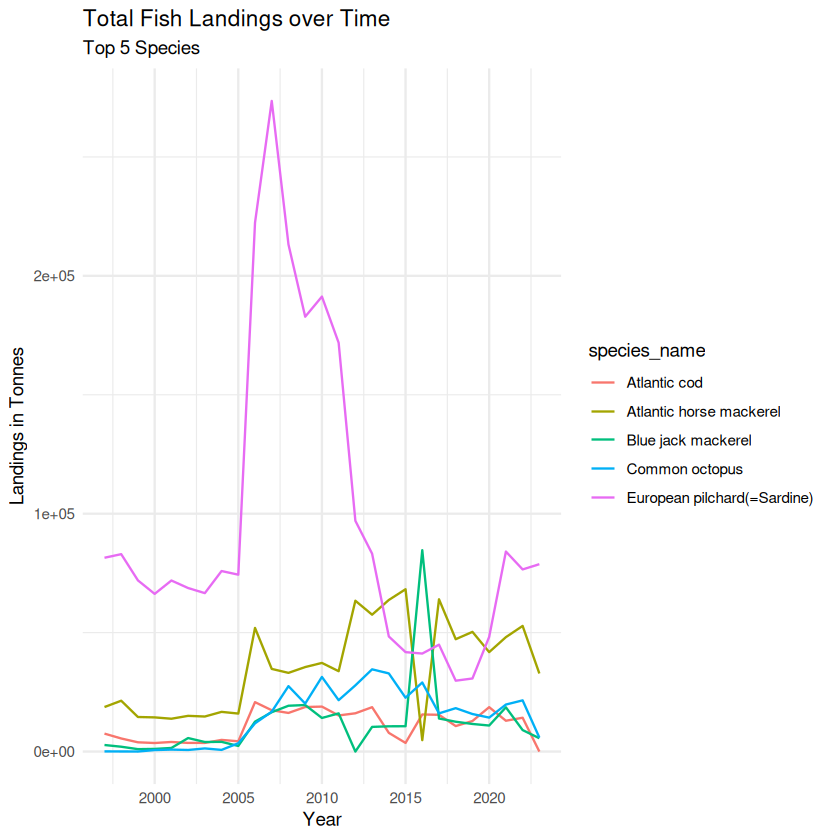

In [82]:
viz4 <- ggplot(top_5_landings, aes(x = year, y = total_landings, color = species_name, group = species_name)) +
  geom_line() +
  labs(
    title = "Total Fish Landings over Time",
    subtitle = "Top 5 Species",
    x = "Year",
    y = "Landings in Tonnes"
  ) +
  theme_minimal()

viz4

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


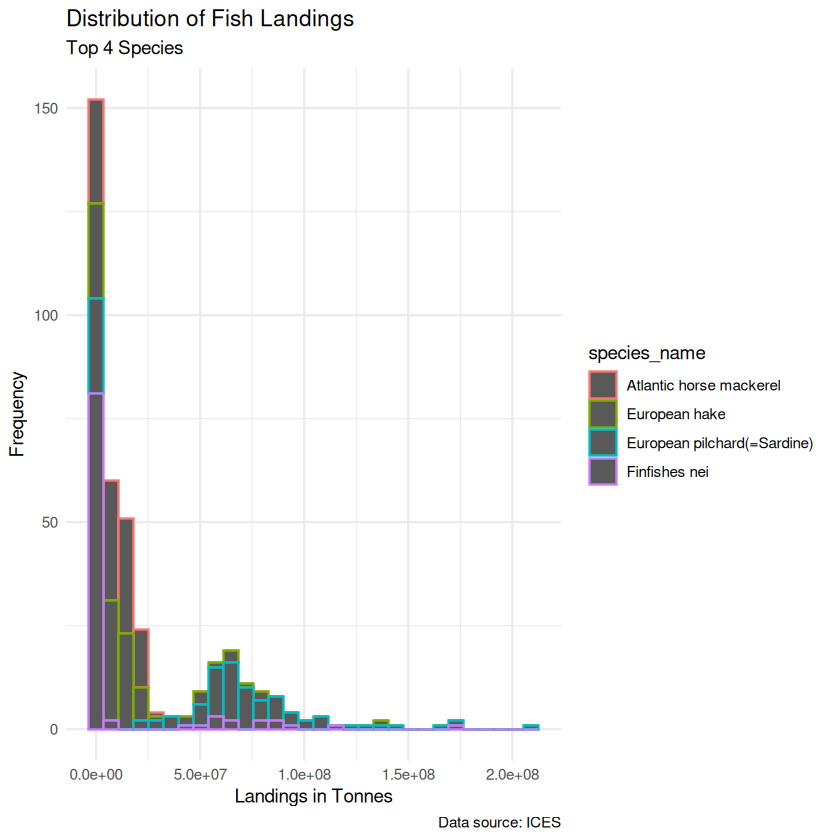

In [50]:
viz1 <- ggplot(pt_sum_landings, aes(x = total_landings, color = species_name, group = species_name)) +
  geom_histogram() +
  labs(
    title = "Distribution of Fish Landings",
    subtitle = "Top 4 Species",  # Optional
    x = "Landings in Tonnes",
    y = "Frequency",
    caption = "Data source: ICES"  # Optional
  ) +
  theme_minimal()

viz1

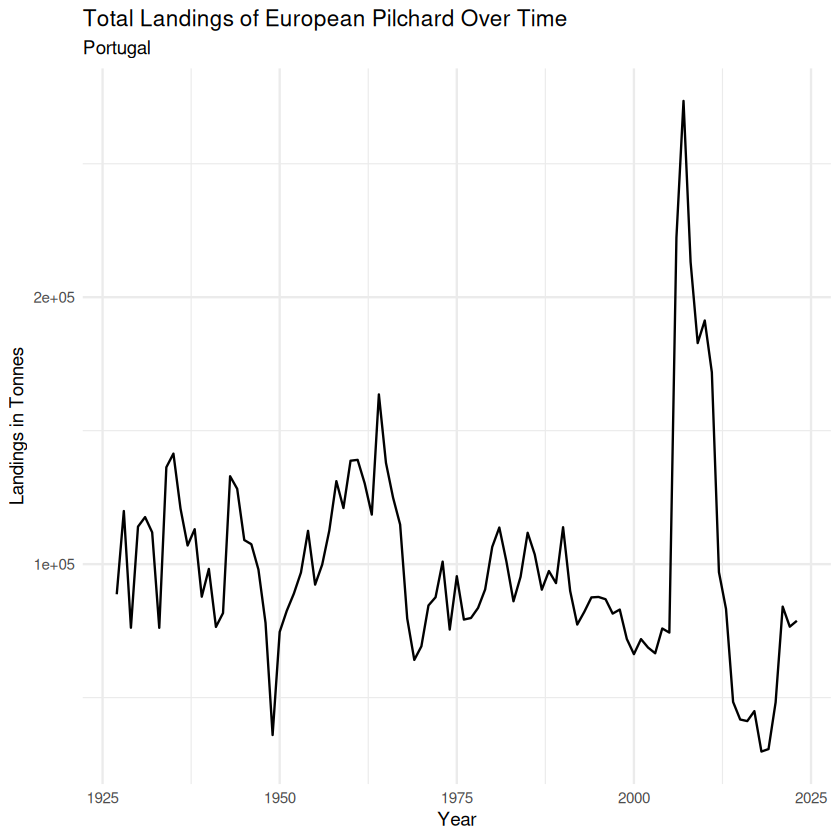

In [44]:
# Combine all 3 datasets
pil <- rbind(pil_1903, pil_1950_longer, pil_2006_longer) %>%
  mutate(year = as.numeric(year))

viz3 <- ggplot(pil, aes(x = year, y = total_landings, group = 1)) +
  geom_line() +
  labs(
    title = "Total Landings of European Pilchard Over Time",
    subtitle = "Portugal",
    x = "Year",
    y = "Landings in Tonnes"
  ) +
  theme_minimal()

viz3

,year,max,min
,<int>,<dbl>,<dbl>
1,1859,-0.44,-0.48
2,1860,-0.47,-0.49
3,1861,-0.51,-0.52
4,1862,-0.55,-0.60
5,1863,-0.36,-0.61
6,1864,-0.37,-0.63


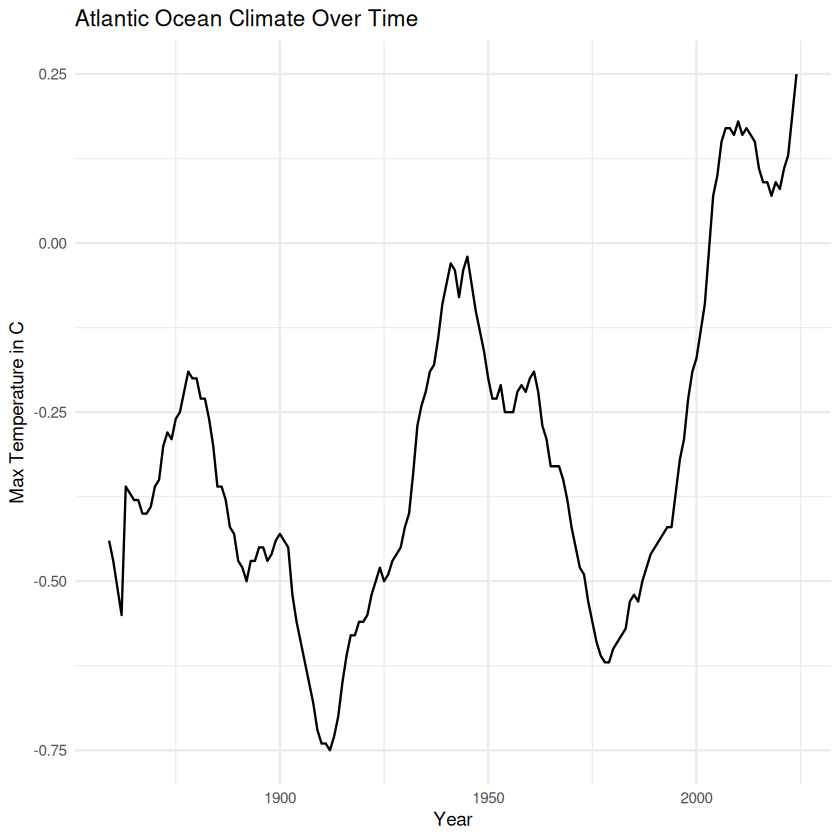

In [83]:
head(atlantic_climate)

viz5 <- ggplot(atlantic_climate, aes(x = year, y = max)) +
  geom_line() +
  labs(
    title = "Atlantic Ocean Climate Over Time",
    x = "Year",
    y = "Max Temperature in C"
  ) +
  theme_minimal()

viz5

In [18]:
final_df <- pt_sum_landings %>%
  left_join(atlantic_climate, by = "year")

head(final_df)

species_code,species_name,year,total_landings,max,min
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
FIN,Finfishes nei,1927,20701,-0.47,-0.64
FIN,Finfishes nei,1928,19178,-0.46,-0.62
FIN,Finfishes nei,1929,25400,-0.45,-0.60
FIN,Finfishes nei,1930,24821,-0.42,-0.58
FIN,Finfishes nei,1931,18395,-0.40,-0.56
FIN,Finfishes nei,1932,21332,-0.34,-0.50


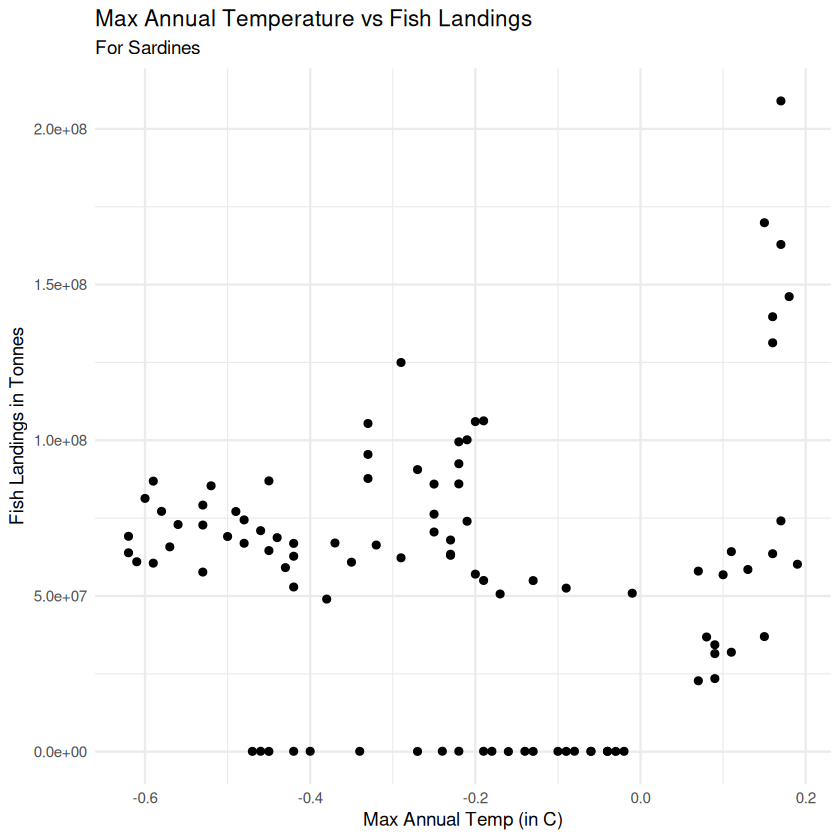

In [34]:
# VISUALIZATION 2: Relationship or Comparison

pil <- final_df %>%
  filter(species_code == "PIL")

hom <- final_df %>%
  filter(species_code == "HOM")

hke <- final_df %>%
  filter(species_code == "HKE")

fin <- final_df %>%
  filter(species_code == "FIN")

viz2 <- ggplot(pil, aes(x = max, y = total_landings)) +
  geom_point() +
  labs(
    title = "Max Annual Temperature vs Fish Landings",
    subtitle = "For Sardines",
    x = "Max Annual Temp (in C)",
    y = "Fish Landings in Tonnes"
  ) +
  theme_minimal()

viz2

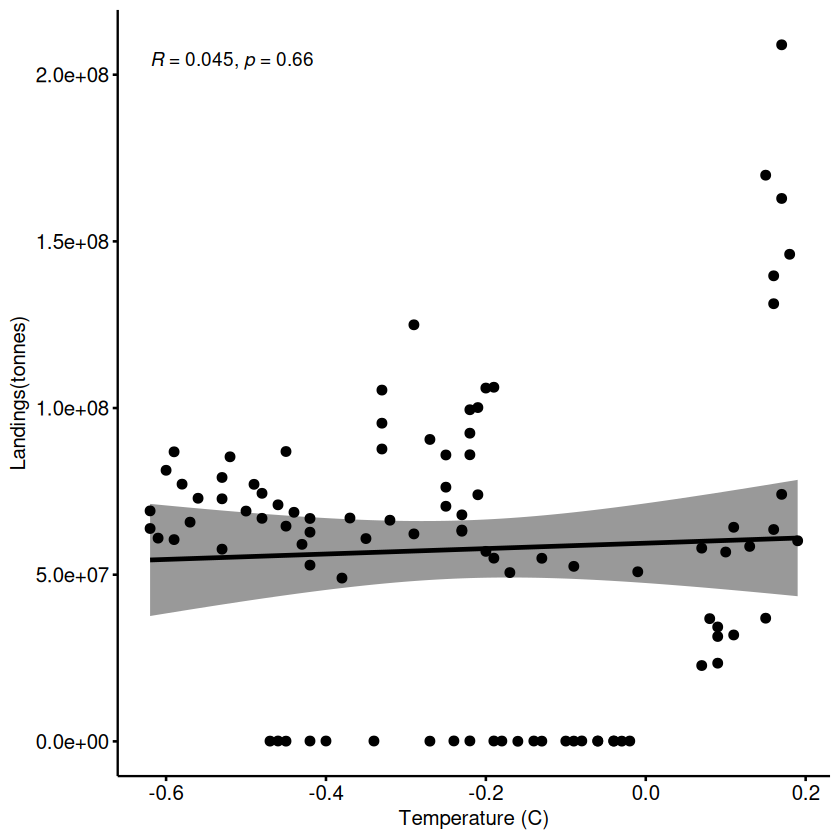

In [22]:
ggscatter(pil, x = "max", y = "total_landings", 
          add = "reg.line", conf.int = TRUE, 
          cor.coef = TRUE, cor.method = "pearson",
          xlab = "Temperature (C)", ylab = "Landings(tonnes)")

In [33]:
ress3 <- cor.test(final_df$max, final_df$total_landings, method='spearman', exact = FALSE)
ress3

#this means climate does not have a big impact on fish catches currently
#


	Spearman's rank correlation rho

data:  final_df$max and final_df$total_landings
S = 11810901, p-value = 2.282e-05
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.2132268 


In [38]:
ress4 <- cor.test(fin$max, fin$total_landings, method='spearman', exact = FALSE)
ress4



	Spearman's rank correlation rho

data:  fin$max and fin$total_landings
S = 216899, p-value = 1.355e-05
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.4260645 


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


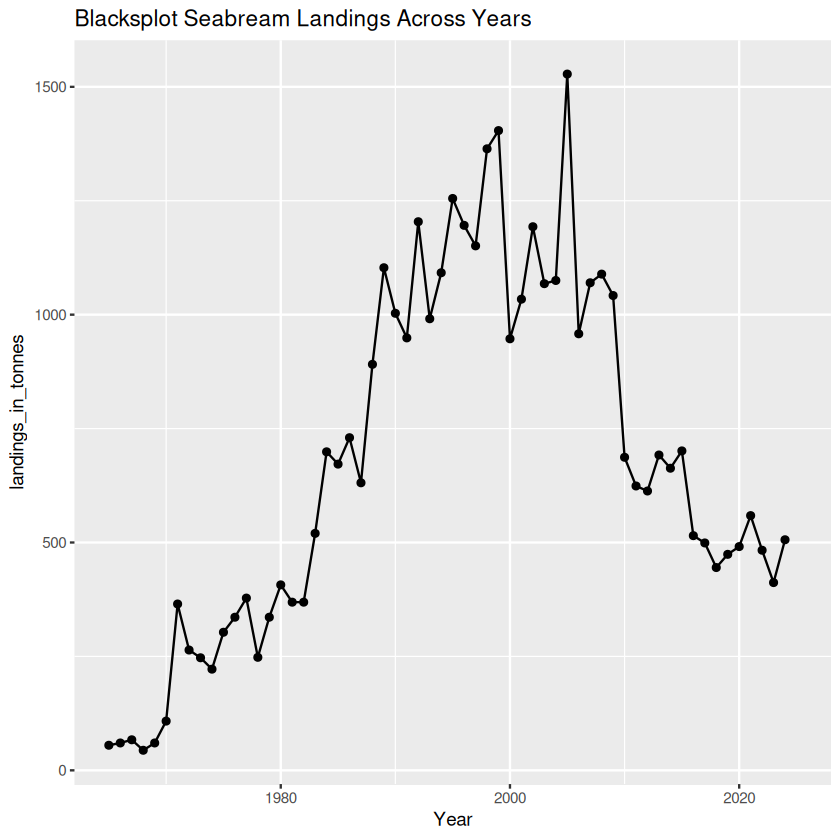

In [19]:
# Plot seabream landings over the years
blackspot_seabream_clean %>% ggplot(aes(x = Year, y = landings_in_tonnes)) +
  geom_line() +
  geom_point() + 
  labs(title = "Blacksplot Seabream Landings Across Years",
       xlab = "Year",
       ylab = "Landings in Tonnes")

In [17]:
#clean saithe dataset
saithe_clean <- saithe %>%
  rename(year = Year,
         landings_in_tonnes = Landings..tonnes.,
         discards_in_tonnes = Discards..tonnes.)

head(saithe_clean)

,year,landings_in_tonnes,discards_in_tonnes
,<int>,<int>,<int>
1,2003,1475,0
2,2004,1603,0
3,2005,925,0
4,2006,773,5
5,2007,728,0
6,2008,442,0


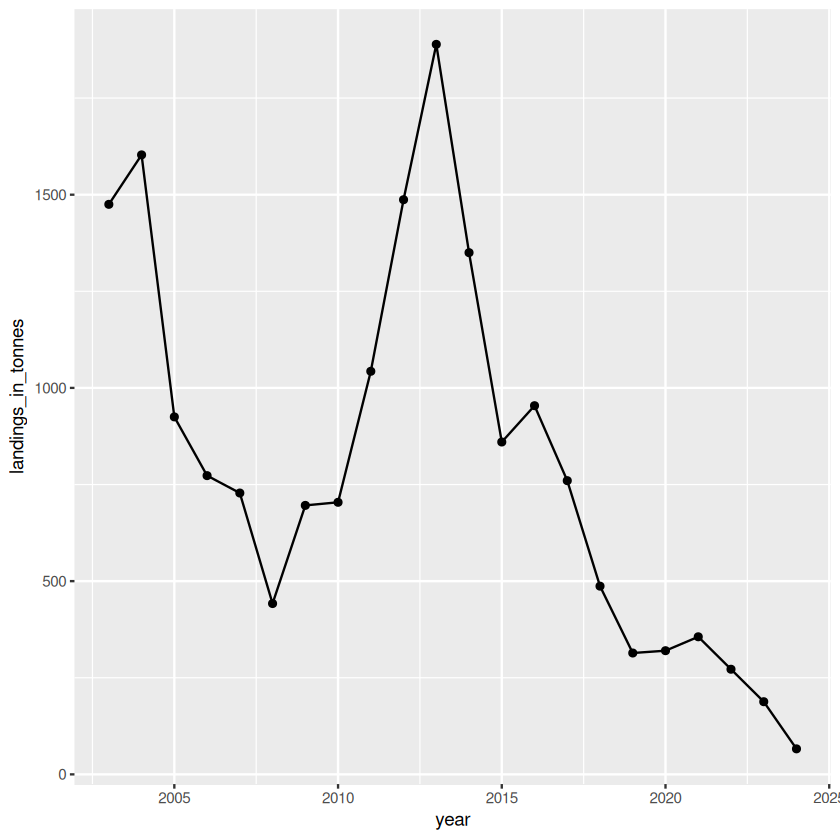

In [18]:
# Plot seabream landings over the years
saithe_clean %>% ggplot(aes(x = year, y = landings_in_tonnes)) +
  geom_line() +
  geom_point()